# cog20 zoom: task-variance clusters and E/I weight distributions

The two questions (supervisor, 2026-10-07), on networks trained on all **20 tasks**:

1. **Task-variance clusters.** Do the biological constraints (rate and wiring budgets) make Yang-2019-style
   functional clusters emerge, compared with the unconstrained network (`control` = the same Dale network,
   no costs)?
2. **Weight distributions.** What happens to the E→E, E→I, I→E and I→I weight distributions under the
   constraints?

Input: a `cmc.moo_zoom` run (`ZOOM_DIR`), one checkpoint per point × seed with weights and per-neuron task
variance. `POINTS` picks and orders the points; `control` must be one of them.

**Confound to keep in mind.** A network that has not learned a task has no structured variance for it, so it
cannot form a cluster for it. If control and constrained networks solve *different* tasks, a difference in
clusters can just mean a difference in what was learned. Section 1.4 redoes the clustering on the tasks that
every point solves.

In [1]:
import contextlib, io, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from cmc.paths import MOO_ZOOM_RUNS_DIR
from cmc.task import default_config
from cmc.train_cog import load_checkpoint, make_dale_model

ZOOM_DIR = MOO_ZOOM_RUNS_DIR / "dale_all_4pt_12seed_50k"
# None = every point of the run, in run order. Otherwise a list; "control" first.
POINTS = ["control", "rate_limited", "wiring_limited", "knee"]
SOLVED_ACC = 0.8          # a task counts as "solved" by a point above this mean accuracy (section 1.4)
K_RANGE = range(2, 21)    # up to one cluster per task

zoom = pd.read_csv(ZOOM_DIR / "runs.csv")
zsum = json.loads((ZOOM_DIR / "summary.json").read_text())
TASKS = zsum["active_tasks"]
POINTS = POINTS or list(zsum["points"])
zoom = zoom[zoom.point.isin(POINTS)]
COLORS = dict(zip(POINTS, ["#444444"] + [plt.cm.tab10(i) for i in range(len(POINTS))]))
ACC = [f"acc_{t}" for t in TASKS]

def load(point, seed):
    with contextlib.redirect_stdout(io.StringIO()):
        model, config, ck = load_checkpoint(ZOOM_DIR / point / f"seed_{seed:02d}.pt")
    W = model.effective_w_rec().detach().numpy()          # W[pre, post]
    return model, ck, W

def seeds(point):
    return sorted(zoom[zoom.point == point].seed)

def representative_seed(point):
    # median-accuracy seed, among feasible seeds if there are any
    sub = zoom[zoom.point == point]
    sub = (sub[sub.is_feasible] if sub.is_feasible.any() else sub).sort_values("min_task_acc")
    return int(sub.iloc[len(sub) // 2].seed)

REP = {p: representative_seed(p) for p in POINTS}
N_E = int(load(POINTS[0], REP[POINTS[0]])[0].n_e)
print(f"{ZOOM_DIR.name}: {len(zoom)} networks, {len(TASKS)} tasks, steps={zsum['steps']}")
print("representative seeds:", REP)

dale_all_4pt_12seed_50k: 48 networks, 20 tasks, steps=50000
representative seeds: {'control': 5, 'rate_limited': 4, 'wiring_limited': 10, 'knee': 0}


## 0. What each point learned

,n,n_feasible,min_acc,mean_acc,rate_budget,conn_budget,metabolic,wiring,conn_frac
point,,,,,,,,,
control,12,12,0.8645,0.9790,NaN,NaN,0.4104,0.0279,0.7332
rate_limited,12,3,0.5342,0.9517,0.0037,0.0237,0.0064,0.0237,0.4952
wiring_limited,12,10,0.6887,0.9477,0.0231,0.0020,0.0314,0.0020,0.0062
knee,12,4,0.5609,0.9238,0.0046,0.0025,0.0071,0.0025,0.0054


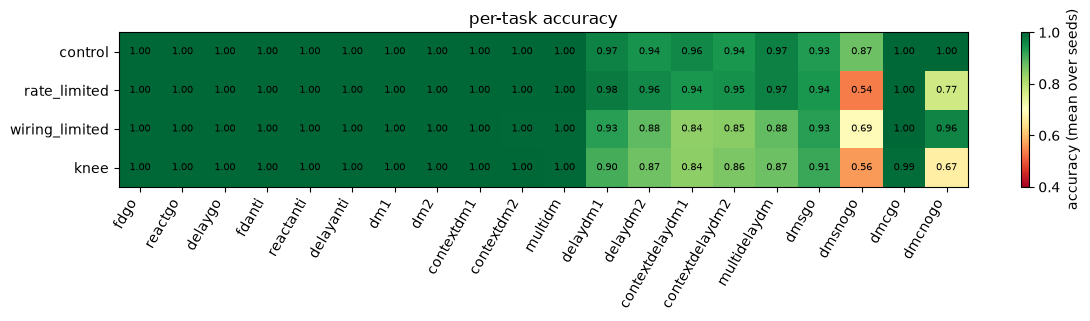

In [2]:
agg = zoom.groupby("point").agg(
    n=("seed", "size"), n_feasible=("is_feasible", "sum"),
    min_acc=("min_task_acc", "mean"), mean_acc=("mean_acc", "mean"),
    rate_budget=("rate_budget", "first"), conn_budget=("conn_budget", "first"),
    metabolic=("metabolic_cost", "mean"), wiring=("wiring_cost", "mean"), conn_frac=("conn_frac", "mean"),
).reindex(POINTS)
display(agg.round(4))

task_acc = zoom.groupby("point")[ACC].mean().reindex(POINTS).set_axis(TASKS, axis=1)
fig, ax = plt.subplots(figsize=(12, 0.45 * len(POINTS) + 1.5))
im = ax.imshow(task_acc.values, cmap="RdYlGn", vmin=0.4, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=60, ha="right")
ax.set_yticks(range(len(POINTS))); ax.set_yticklabels(POINTS)
for i in range(len(POINTS)):
    for j in range(len(TASKS)):
        ax.text(j, i, f"{task_acc.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, label="accuracy (mean over seeds)")
ax.set_title("per-task accuracy"); plt.tight_layout(); plt.show()

## 0.1 The zoom points on the front (3D, interactive)

Background: every network of the `cmc.moo` run the points were picked from (`FRONT_DIR`; `None` = find the
run whose budgets match the zoom points). Light blue = front, silver = feasible but dominated, grey x = fails
the 0.6 cutoff. Coloured: every seed of each zoom point (x = infeasible seed); diamond = mean over seeds.
Coloured surface: the front, triangulated over (metabolic, wiring) and coloured by accuracy. Orange plane:
min_task_acc = 0.6. Accuracy axis 0-1. Drag to rotate, hover for values.

In [3]:
import plotly.graph_objects as go
from cmc.front import FEASIBLE_MIN_TASK_ACC, compute_front
from cmc.paths import MOO_RUNS_DIR

FRONT_DIR = None
OBJ = ("min_task_acc", "metabolic_cost", "wiring_cost")

def find_front_run():
    budgeted = {k: v for k, v in zsum["points"].items() if k in POINTS and v["rate_budget"] is not None}
    for run in sorted(MOO_RUNS_DIR.iterdir()):
        csv = run / "runs.csv"
        if not csv.exists() or "rate_budget" not in pd.read_csv(csv, nrows=1).columns:
            continue
        m = pd.read_csv(csv)
        if budgeted and all(np.any(np.isclose(m.rate_budget, v["rate_budget"]) & np.isclose(m.conn_budget, v["conn_budget"]))
                            for v in budgeted.values()):
            return run
    return None

FRONT_DIR = FRONT_DIR or find_front_run()
if FRONT_DIR is not None:
    moo = pd.read_csv(Path(FRONT_DIR) / "runs.csv").drop_duplicates(["x0", "x1"]).reset_index(drop=True)
    moo["is_feasible"] = moo.min_task_acc >= FEASIBLE_MIN_TASK_ACC
    moo["is_pareto"], _ = compute_front(moo.to_dict("records"), OBJ)
    print(f"front run: {Path(FRONT_DIR).name}  ({len(moo)} networks, {int(moo.is_feasible.sum())} feasible, "
          f"{int(moo.is_pareto.sum())} on the front)")
else:
    moo = pd.DataFrame(columns=list(OBJ) + ["conn_frac", "is_feasible", "is_pareto"])
    print("no moo run contains these budgets: plotting the zoom networks only")

def xyz(sub):
    return dict(x=np.log10(sub.metabolic_cost.astype(float)), y=np.log10(sub.wiring_cost.astype(float)),
                z=sub.min_task_acc.astype(float))

def hov(sub, label):
    seed = lambda r: f" seed {r.seed}" if hasattr(r, "seed") and label != "moo front" else ""
    budget = lambda r: (f"<br>budgets: rate {r.rate_budget:.4g}, wiring {r.conn_budget:.4g}"
                        if hasattr(r, "rate_budget") and pd.notna(r.rate_budget) else "")
    return [f"{label}{seed(r)}<br>min_task_acc={r.min_task_acc:.3f}<br>metabolic={r.metabolic_cost:.4f}  "
            f"wiring={r.wiring_cost:.4f}  conn_frac={r.conn_frac:.3f}{budget(r)}" for r in sub.itertuples()]

bad = moo[~moo.is_feasible.astype(bool)]
dom = moo[moo.is_feasible.astype(bool) & ~moo.is_pareto.astype(bool)]
fr = moo[moo.is_pareto.astype(bool)]
traces = [
    go.Scatter3d(**xyz(bad), mode="markers", name="moo: fails a task", marker=dict(size=2, color="lightgrey", symbol="x"), hoverinfo="skip"),
    go.Scatter3d(**xyz(dom), mode="markers", name="moo: dominated", marker=dict(size=2, color="silver", opacity=0.5), hoverinfo="skip"),
    go.Scatter3d(**xyz(fr), mode="markers", name=f"moo front ({len(fr)})", marker=dict(size=3, color="#9ecae1", opacity=0.7),
                 hovertext=hov(fr, "moo front"), hoverinfo="text"),
]
if len(fr) >= 3:
    # front as a surface: triangulated in the (metabolic, wiring) plane
    traces.append(go.Mesh3d(**xyz(fr), delaunayaxis="z", intensity=fr.min_task_acc.astype(float),
                            colorscale="Viridis", cmin=0, cmax=1, opacity=0.55, name="front surface",
                            showlegend=True, showscale=True, colorbar=dict(title="min_task_acc", x=1.02, len=0.6),
                            hoverinfo="skip"))
hex_ = lambda c: c if isinstance(c, str) else "#%02x%02x%02x" % tuple(int(255 * v) for v in c[:3])
for p in POINTS:
    sub = zoom[zoom.point == p]
    for feas_, sym in ((True, "circle"), (False, "x")):
        s_ = sub[sub.is_feasible == feas_]
        if len(s_):
            traces.append(go.Scatter3d(**xyz(s_), mode="markers", legendgroup=p, showlegend=False,
                                       marker=dict(size=4, color=hex_(COLORS[p]), symbol=sym, opacity=0.8),
                                       hovertext=hov(s_, p), hoverinfo="text"))
    m = sub[["metabolic_cost", "wiring_cost", "min_task_acc"]].mean()
    traces.append(go.Scatter3d(x=[np.log10(m.metabolic_cost)], y=[np.log10(m.wiring_cost)], z=[m.min_task_acc],
                               mode="markers", name=f"{p} ({int(sub.is_feasible.sum())}/{len(sub)} feasible)", legendgroup=p,
                               marker=dict(size=9, color=hex_(COLORS[p]), symbol="diamond", line=dict(color="black", width=1)),
                               hovertext=[f"{p} mean of {len(sub)} seeds<br>min_task_acc={m.min_task_acc:.3f} ± {sub.min_task_acc.std():.3f}"],
                               hoverinfo="text"))

allx = np.log10(pd.concat([moo.metabolic_cost, zoom.metabolic_cost]).astype(float))
ally = np.log10(pd.concat([moo.wiring_cost, zoom.wiring_cost]).astype(float))
pad = lambda v: (v.min() - 0.05 * (v.max() - v.min()), v.max() + 0.05 * (v.max() - v.min()))
(x0, x1), (y0, y1) = pad(allx), pad(ally)
traces.append(go.Surface(x=[x0, x1], y=[y0, y1], z=[[FEASIBLE_MIN_TASK_ACC] * 2] * 2,
                         colorscale=[[0, "orange"], [1, "orange"]], opacity=0.2, showscale=False,
                         name=f"acceptable: min_task_acc = {FEASIBLE_MIN_TASK_ACC}", showlegend=True, hoverinfo="skip"))
fig = go.Figure(traces)
fig.update_layout(title=f"Zoom points on the budget front — {Path(FRONT_DIR).name if FRONT_DIR else ZOOM_DIR.name}",
                  scene=dict(xaxis_title="log10(metabolic cost)", yaxis_title="log10(wiring cost)",
                             zaxis_title="min_task_acc", zaxis=dict(range=[0, 1]), aspectmode="cube"),
                  width=980, height=740, legend=dict(x=0.0, y=1.0))
fig.show()

front run: dale_all_nsga3_budget_p48g3_50k  (144 networks, 118 feasible, 27 on the front)


## 0.2 The budget plane (as in `moo_pareto_analysis.ipynb`)

Every network of the front run at its (rate budget, wiring budget), coloured by worst-task accuracy
(interpolated between networks); bold line: min_task_acc = 0.6; x: fails a task. Stars: the zoom points,
labelled with their mean accuracy over seeds. The control has no budget, so it is not on this plane.

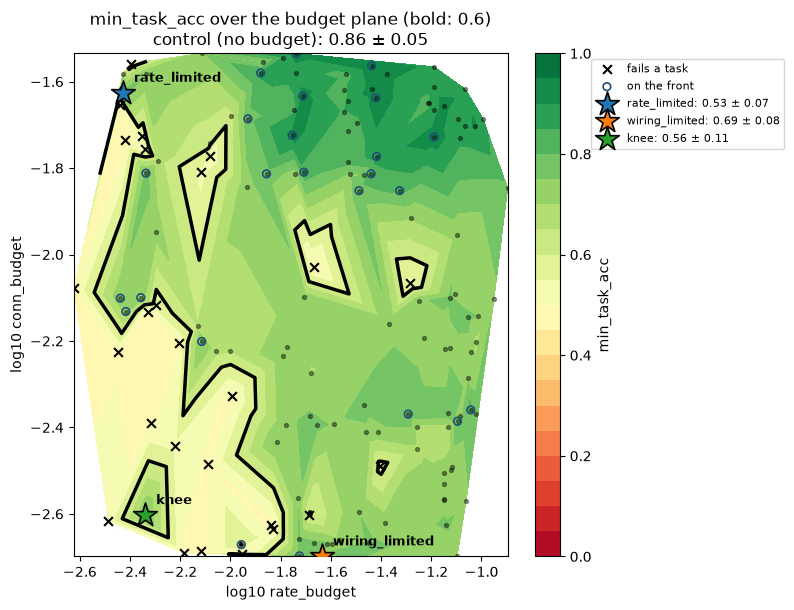

In [4]:
if FRONT_DIR is not None:
    x, y = np.log10(moo.rate_budget), np.log10(moo.conn_budget)
    ok = moo.is_feasible.astype(bool)
    fig, ax = plt.subplots(figsize=(8, 6.2))
    tc = ax.tricontourf(x, y, moo.min_task_acc, levels=np.linspace(0, 1, 21), cmap="RdYlGn")
    ax.tricontour(x, y, moo.min_task_acc, levels=[FEASIBLE_MIN_TASK_ACC], colors="k", linewidths=2.5)
    ax.scatter(x[ok], y[ok], s=8, c="k", alpha=.4)
    ax.scatter(x[~ok], y[~ok], s=40, marker="x", c="k", label="fails a task")
    fr_ = moo[moo.is_pareto.astype(bool)]
    ax.scatter(np.log10(fr_.rate_budget), np.log10(fr_.conn_budget), s=30, facecolors="none",
               edgecolors="#1f4e79", lw=1.2, label="on the front")
    for p in POINTS:
        sub_ = zoom[zoom.point == p]
        if sub_.rate_budget.isna().all():
            continue
        px, py = np.log10(sub_.rate_budget.iloc[0]), np.log10(sub_.conn_budget.iloc[0])
        ax.scatter(px, py, s=320, marker="*", color=hex_(COLORS[p]), edgecolors="k", lw=1.2, zorder=5,
                   label=f"{p}: {sub_.min_task_acc.mean():.2f} ± {sub_.min_task_acc.std():.2f}")
        ax.annotate(p, (px, py), xytext=(8, 8), textcoords="offset points", fontsize=9, weight="bold")
    ctrl = zoom[zoom.point == "control"]
    if len(ctrl):
        ax.set_title(f"min_task_acc over the budget plane (bold: {FEASIBLE_MIN_TASK_ACC})\n"
                     f"control (no budget): {ctrl.min_task_acc.mean():.2f} ± {ctrl.min_task_acc.std():.2f}")
    fig.colorbar(tc, ax=ax, label="min_task_acc", ticks=np.linspace(0, 1, 6))
    ax.set_xlabel("log10 rate_budget"); ax.set_ylabel("log10 conn_budget")
    ax.legend(loc="upper left", bbox_to_anchor=(1.18, 1), fontsize=8)
    plt.tight_layout(); plt.show()

# 1. Task-variance clusters

**Task variance** (Yang et al. 2019) of neuron *i* for task *t*: the variance of its activity across trials,
at each time step after fixation onset, averaged over time (noise-free eval trials). Computed by
`runner.activity_summary` and stored in each checkpoint.

**Clustering** (same as `moo_zoom_analysis` §2.1, k up to 20):
1. Keep active neurons (total task variance > 1% of the network's maximum).
2. Normalise each neuron's 20-task vector to its maximum.
3. k-means for k = 2-20; pick k by silhouette.

**Is there real cluster structure?** Silhouette alone is hard to read: k-means always returns clusters. The
**null** shuffles each neuron's task-variance vector across tasks independently (keeps how selective each
neuron is, destroys which tasks go together) and reruns k-means at the chosen k. Clusters are real if the
observed silhouette is clearly above the null.

**Specialisation:** per neuron, the number of tasks whose normalised variance exceeds 0.5. 1 = the neuron
works for a single task; 20 = it varies on everything.

In [5]:
def tv_clusters(tv, k_range=K_RANGE, seed=0, tasks_idx=None):
    tv = np.asarray(tv)
    if tasks_idx is not None:
        tv = tv[tasks_idx]
    total = tv.sum(axis=0)
    active = total > 1e-2 * total.max()
    norm = tv[:, active] / tv[:, active].max(axis=0, keepdims=True)
    X = norm.T
    scores, labs = {}, {}
    for k in k_range:
        if k >= len(X):
            break
        labs[k] = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X)
        scores[k] = silhouette_score(X, labs[k])
    k = max(scores, key=scores.get)
    lab = labs[k]
    labels = np.full(tv.shape[1], -1)
    # order clusters by preferred task so plots are comparable across networks
    pref = {c: int(np.argmax(norm[:, lab == c].mean(axis=1))) for c in range(k)}
    order = sorted(range(k), key=lambda c: (pref[c], -norm[pref[c], lab == c].mean()))
    remap = {c: i for i, c in enumerate(order)}
    labels[active] = [remap[c] for c in lab]
    return dict(active=active, X=X, norm_full=tv / np.maximum(tv.max(axis=0, keepdims=True), 1e-30),
                labels=labels, k=k, silhouette=scores[k], scores=scores,
                pref_tasks=[pref[c] for c in order])

def null_silhouette(X, k, n=5, seed=0):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        Xs = np.array([rng.permutation(row) for row in X])
        out.append(silhouette_score(Xs, KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(Xs)))
    return float(np.mean(out))

CL = {}       # (point, seed) -> clustering on all tasks
rows = []
for p in POINTS:
    for s in seeds(p):
        _, ck, _ = load(p, s)
        cl = tv_clusters(ck["task_variance"])
        CL[p, s] = cl
        n_sel = (cl["X"] > 0.5).sum(axis=1)
        rows.append({"point": p, "seed": s, "feasible": bool(zoom[(zoom.point == p) & (zoom.seed == s)].is_feasible.iloc[0]),
                     "n_active": int(cl["active"].sum()), "k": cl["k"], "silhouette": cl["silhouette"],
                     "null_silhouette": null_silhouette(cl["X"], cl["k"]),
                     "tasks_per_neuron": float(n_sel.mean()), "single_task_frac": float((n_sel == 1).mean())})
tvstats = pd.DataFrame(rows)
tvstats["silhouette_excess"] = tvstats.silhouette - tvstats.null_silhouette
display(tvstats.groupby("point")[["n_active", "k", "silhouette", "null_silhouette", "silhouette_excess",
                                  "tasks_per_neuron", "single_task_frac"]].agg(["mean", "std"]).reindex(POINTS).round(3))

n_active              k        silhouette         \
                   mean     std   mean    std       mean    std   
point                                                             
control         255.667   0.492   2.00  0.000      0.220  0.024   
rate_limited    255.500   0.674   6.50  3.477      0.216  0.017   
wiring_limited  229.333  11.949  11.50  5.000      0.223  0.022   
knee            200.167  11.831  15.75  3.049      0.253  0.016   

               null_silhouette        silhouette_excess         \
                          mean    std              mean    std   
point                                                            
control                  0.079  0.012             0.141  0.018   
rate_limited             0.068  0.010             0.148  0.021   
wiring_limited           0.086  0.015             0.137  0.018   
knee                     0.112  0.012             0.141  0.014   

               tasks_per_neuron        single_task_frac         
                           mean    std             mean    std  
point                                                           
control                   4.977  0.325            0.073  0.039  
rate_limited              3.584  0.147            0.164  0.023  
wiring_limited            3.507  0.233            0.198  0.023  
knee                      3.278  0.183            0.245  0.022

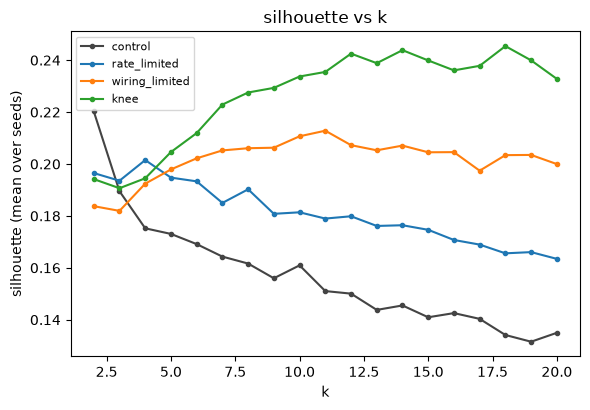

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4.2))
for p in POINTS:
    sc = np.array([[CL[p, s]["scores"].get(k, np.nan) for k in K_RANGE] for s in seeds(p)])
    axes.plot(list(K_RANGE), np.nanmean(sc, axis=0), "-o", ms=3, color=COLORS[p], label=p)
axes.set_xlabel("k"); axes.set_ylabel("silhouette (mean over seeds)"); axes.legend(fontsize=8)
axes.set_title("silhouette vs k")
# for ax, col, title in [(axes[1], "silhouette_excess", "silhouette − shuffled null (> 0: real clusters)"),
#                        (axes[2], "tasks_per_neuron", "tasks per neuron (norm. TV > 0.5)")]:
#     g = tvstats.groupby("point")[col].agg(["mean", "std"]).reindex(POINTS)
#     ax.bar(POINTS, g["mean"], yerr=g["std"], color=[COLORS[p] for p in POINTS], capsize=3)
#     for i, p in enumerate(POINTS):
#         ax.scatter([i] * len(seeds(p)), tvstats[tvstats.point == p][col], color="k", s=8, zorder=3)
#     ax.set_title(title); ax.tick_params(axis="x", rotation=30)
# axes[1].axhline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

## 1.2 Normalised task-variance maps (Yang et al. 2019, Fig. 2b layout)

Same layout as Yang's `plot_variance` (`gyyang/multitask`, `analysis/clustering.py`): tasks on the y-axis,
active units on the x-axis grouped by cluster, `cmap="hot"`, colour range 0-1, and a coloured strip with the
cluster numbers underneath instead of boundary lines. Representative seed per point.

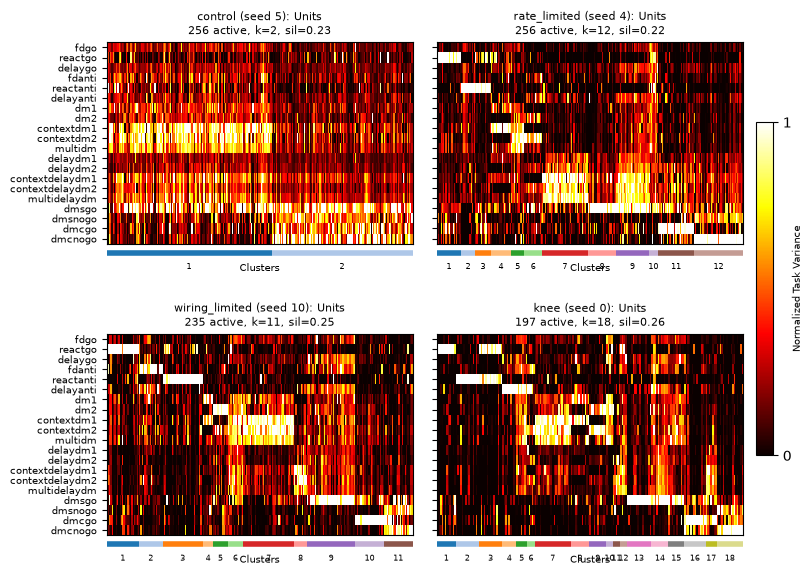

In [8]:
CLUSTER_COLORS = plt.cm.tab20(np.linspace(0, 1, 20))

def plot_variance(ax, cl, title):
    idx = np.flatnonzero(cl["active"])
    idx = idx[np.lexsort((idx >= N_E, cl["labels"][idx]))]          # by cluster, E before I inside
    im = ax.imshow(cl["norm_full"][:, idx], cmap="hot", aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS, fontsize=7)
    ax.set_xticks([])
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("Clusters", fontsize=7, labelpad=14)
    labs = cl["labels"][idx]
    y = len(TASKS) - 0.5 + 0.9
    for c in range(cl["k"]):
        pos = np.flatnonzero(labs == c)
        if len(pos) == 0:
            continue
        ax.plot([pos[0] - 0.5, pos[-1] + 0.5], [y, y], lw=4, solid_capstyle="butt",
                color=CLUSTER_COLORS[c % 20], clip_on=False)
        ax.text(pos.mean(), y + 1.0, str(c + 1), ha="center", va="top", fontsize=6)
    ax.set_ylim(len(TASKS) - 0.5, -0.5)
    return im

nrows = int(np.ceil(len(POINTS) / 2))
fig, axes = plt.subplots(nrows, 2, figsize=(2 * 4.3, 3.2 * nrows), squeeze=False)

for i, (ax, p) in enumerate(zip(axes.flat, POINTS)):
    cl = CL[p, REP[p]]
    im = plot_variance(ax, cl, f"{p} (seed {REP[p]}): Units\n{cl['active'].sum()} active, k={cl['k']}, sil={cl['silhouette']:.2f}")
    if i % 2 == 1:                      # right column: no task labels
        ax.set_yticklabels([])
for ax in axes.flat[len(POINTS):]:      # odd number of points: hide the empty panel
    ax.axis("off")
fig.subplots_adjust(hspace=0.45, wspace=0.08)
cb = fig.colorbar(im, ax=axes, ticks=[0, 1], fraction=0.025, pad=0.02)
cb.set_label("Normalized Task Variance", fontsize=7, labelpad=0)
plt.show()

## 1.3 Cluster × task
Mean normalised task variance of each cluster for each task, same orientation (tasks on y, clusters on x) and colormap.

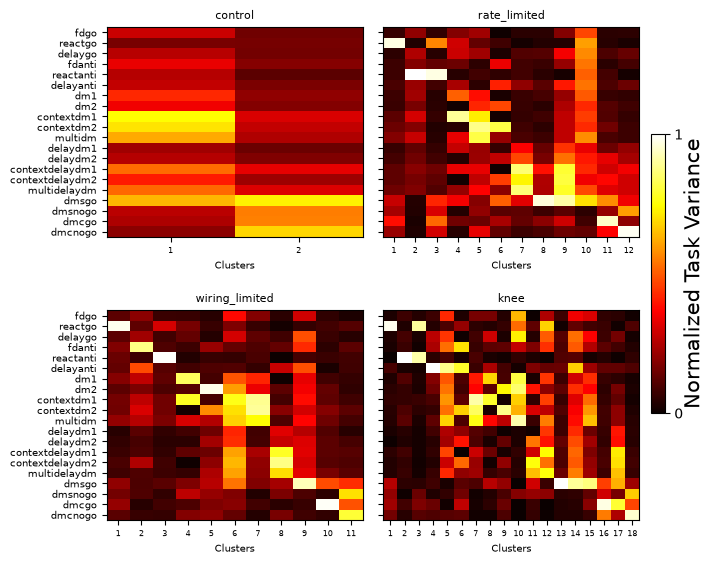

In [15]:
nrows = int(np.ceil(len(POINTS) / 2))
fig, axes = plt.subplots(nrows, 2, figsize=(2 * 3.6, 3.2 * nrows), squeeze=False)

for i, (ax, p) in enumerate(zip(axes.flat, POINTS)):
    cl = CL[p, REP[p]]
    M = np.array([cl["norm_full"][:, cl["labels"] == c].mean(axis=1) for c in range(cl["k"])]).T   # tasks x clusters
    im = ax.imshow(M, aspect="auto", cmap="hot", vmin=0, vmax=1, interpolation="nearest")
    ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS if i % 2 == 0 else [], fontsize=7)
    ax.set_xticks(range(cl["k"])); ax.set_xticklabels([str(c + 1) for c in range(cl["k"])], fontsize=6)
    ax.set_xlabel("Clusters", fontsize=7)
    ax.set_title(p, fontsize=8)
for ax in axes.flat[len(POINTS):]:      # odd number of points: hide the empty panel
    ax.axis("off")
fig.subplots_adjust(hspace=0.35, wspace=0.08)
cb = fig.colorbar(im, ax=axes, ticks=[0, 1], fraction=0.025, pad=0.02)
cb.set_label("Normalized Task Variance", fontsize=15, labelpad=0)
plt.show()

## 1.4 Controlling for what was learned

Clustering again, on only the tasks that **every** point solves (mean accuracy ≥ `SOLVED_ACC`). If the
constrained-vs-control difference survives here, it is not just "control did not learn the delay tasks".

In [17]:
solved = [i for i, t in enumerate(TASKS) if (task_acc[t] >= SOLVED_ACC).all()]
print(f"{len(solved)}/{len(TASKS)} tasks solved by every point:", [TASKS[i] for i in solved])
rows = []
if len(solved) >= 3:
    for p in POINTS:
        for s in seeds(p):
            _, ck, _ = load(p, s)
            cl = tv_clusters(ck["task_variance"], k_range=range(2, len(solved) + 1), tasks_idx=solved)
            rows.append({"point": p, "seed": s, "k": cl["k"], "silhouette": cl["silhouette"],
                         "null_silhouette": null_silhouette(cl["X"], cl["k"])})
    sub = pd.DataFrame(rows)
    sub["silhouette_excess"] = sub.silhouette - sub.null_silhouette
    display(sub.groupby("point")[["k", "silhouette", "null_silhouette", "silhouette_excess"]]
            .agg(["mean", "std"]).reindex(POINTS).round(3))

18/20 tasks solved by every point: ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm', 'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm', 'dmsgo', 'dmcgo']


k        silhouette        null_silhouette         \
                  mean    std       mean    std            mean    std   
point                                                                    
control          2.500  0.905      0.224  0.019           0.078  0.012   
rate_limited     3.833  1.467      0.227  0.011           0.066  0.004   
wiring_limited  12.833  3.713      0.235  0.026           0.108  0.018   
knee            13.250  2.800      0.263  0.014           0.121  0.013   

               silhouette_excess         
                            mean    std  
point                                    
control                    0.146  0.013  
rate_limited               0.161  0.012  
wiring_limited             0.127  0.021  
knee                       0.143  0.013

# 2. E→E, E→I, I→E and I→I weight distributions

`W[pre, post]`, so E→I is the block of rows E, columns I. Magnitudes are |W| (inhibitory weights are
negative in W). For reference, **init** is the same network before training (rebuilt from its seed), so
"what the constraints did" is separable from "what training did".

A synapse counts as **present** if its E/I-normalised magnitude exceeds 1e-2 (the `conn_frac` threshold);
the wiring budget pushes pruned synapses to ~1e-8, far below it.

In [18]:
BLOCKS = {"E→E": (slice(0, N_E), slice(0, N_E)), "E→I": (slice(0, N_E), slice(N_E, None)),
          "I→E": (slice(N_E, None), slice(0, N_E)), "I→I": (slice(N_E, None), slice(N_E, None))}
THRESH = 1e-2

def init_W(ck):
    with contextlib.redirect_stdout(io.StringIO()):
        cfg = default_config(n_eachring=ck["config"].get("n_eachring", 16), seed=0)
        m = make_dale_model(cfg, **ck["model_kwargs"])
    return m.effective_w_rec().detach().numpy()

def block_values(model, W):
    mag_norm = np.abs(W) / model.ei_row_scale().numpy()[:, None]
    mask = model.no_autapse.numpy() > 0
    out = {}
    for b, (pre, post) in BLOCKS.items():
        m = mask[pre, post]
        present = (mag_norm[pre, post] > THRESH) & m
        out[b] = dict(vals=np.abs(W[pre, post])[present], n_possible=int(m.sum()))
    return out

VALS = {}     # (point, block) -> pooled |w| of present synapses
rows = []
for p in POINTS + ["init"]:
    src = [(p, s) for s in seeds(p)] if p != "init" else [("control", s) for s in seeds("control")]
    for (q, s) in src:
        model, ck, W = load(q, s)
        if p == "init":
            W = init_W(ck)
        for b, d in block_values(model, W).items():
            v = d["vals"]
            VALS.setdefault((p, b), []).append(v)
            lv = np.log10(v) if len(v) else np.array([np.nan])
            top = np.sort(v)[::-1]
            rows.append({"point": p, "seed": s, "block": b, "density": len(v) / d["n_possible"],
                         "mean": v.mean() if len(v) else 0.0, "median": np.median(v) if len(v) else 0.0,
                         "CV": v.std() / v.mean() if len(v) else np.nan,
                         "log10 mean": np.nanmean(lv), "log10 std": np.nanstd(lv),
                         "top10% share": top[: max(1, len(top) // 10)].sum() / top.sum() if len(v) else np.nan,
                         "total": v.sum()})
VALS = {k: np.concatenate(v) for k, v in VALS.items()}
wstats = pd.DataFrame(rows)
ORDER = ["init"] + POINTS
display(wstats.groupby(["block", "point"])[["density", "mean", "median", "CV", "log10 std", "top10% share", "total"]]
        .mean().reindex(ORDER, level=1).round(4))

density    mean  median      CV  log10 std  \
block point                                                        
E→E   init             0.7594  0.0331  0.0290  0.5466     0.2347   
      control          0.7284  0.0358  0.0287  0.7279     0.2645   
      rate_limited     0.4740  0.0446  0.0289  1.1548     0.3288   
      wiring_limited   0.0036  0.4280  0.2864  1.1365     0.5216   
      knee             0.0039  0.6321  0.4455  1.1180     0.5218   
E→I   init             0.7596  0.0331  0.0290  0.5478     0.2351   
      control          0.7390  0.0369  0.0298  0.7216     0.2672   
      rate_limited     0.5281  0.0485  0.0321  1.0265     0.3354   
      wiring_limited   0.0070  0.4088  0.3114  0.8770     0.4757   
      knee             0.0052  0.4623  0.4124  0.7542     0.4452   
I→E   init             0.7595  0.1299  0.1139  0.5469     0.2349   
      control          0.7412  0.1445  0.1162  0.7068     0.2680   
      rate_limited     0.5344  0.1863  0.1305  0.9130     0.3251   
      wiring_limited   0.0133  0.8829  0.6700  1.0383     0.3953   
      knee             0.0110  1.1677  0.8515  1.0826     0.4065   
I→I   init             0.7585  0.1296  0.1135  0.5486     0.2350   
      control          0.7521  0.1404  0.1159  0.6747     0.2579   
      rate_limited     0.5380  0.1657  0.1241  0.7870     0.3000   
      wiring_limited   0.0144  0.6919  0.5987  0.6830     0.3628   
      knee             0.0079  0.7400  0.5962  0.8415     0.3616   

                      top10% share        total  
block point                                      
E→E   init                  0.2165  1045.155762  
      control               0.2606  1083.145142  
      rate_limited          0.3544   872.402100  
      wiring_limited        0.3389    62.386501  
      knee                  0.3502    99.221001  
E→I   init                  0.2169   267.725311  
      control               0.2588   290.397003  
      rate_limited          0.3414   270.541809  
      wiring_limited        0.2812    30.182800  
      knee                  0.2318    25.096701  
I→E   init                  0.2165  1050.642212  
      control               0.2588  1140.926147  
      rate_limited          0.3135  1051.834595  
      wiring_limited        0.3104   123.181503  
      knee                  0.3246   135.523407  
I→I   init                  0.2164   261.901703  
      control               0.2475   281.139496  
      rate_limited          0.2807   235.449295  
      wiring_limited        0.2169    26.046801  
      knee                  0.2268    15.388100

## 2.1 Distributions (present synapses, pooled over seeds)
Log-x histograms, normalised to density; the legend gives the fraction of possible synapses present.

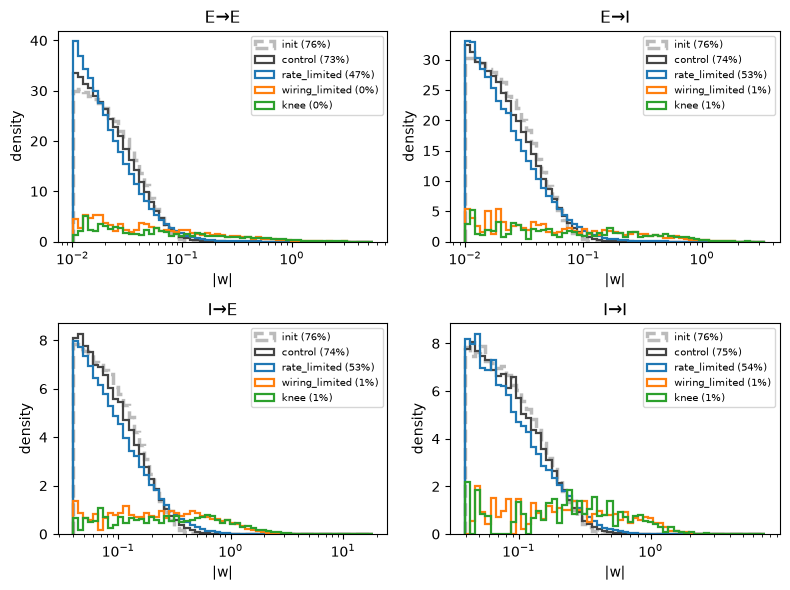

In [26]:
COL = {"init": "#bbbbbb", **COLORS}
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, b in zip(axes.flat, BLOCKS):
    allv = np.concatenate([VALS[(p, b)] for p in ORDER if len(VALS[(p, b)])])
    bins = np.logspace(np.log10(np.percentile(allv, 0.1)), np.log10(allv.max()), 60)
    for p in ORDER:
        v = VALS[(p, b)]
        dens = wstats[(wstats.point == p) & (wstats.block == b)].density.mean()
        ax.hist(v, bins=bins, density=True, histtype="step", lw=1.6 if p != "init" else 2.5,
                color=COL[p], label=f"{p} ({dens:.0%})", ls="--" if p == "init" else "-")
    ax.set_xscale("log"); ax.set_title(b); ax.set_xlabel("|w|"); ax.set_ylabel("density")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 2.2 Cumulative distributions
Easier for comparing shape (heavier tail = curve reaching 1 later).

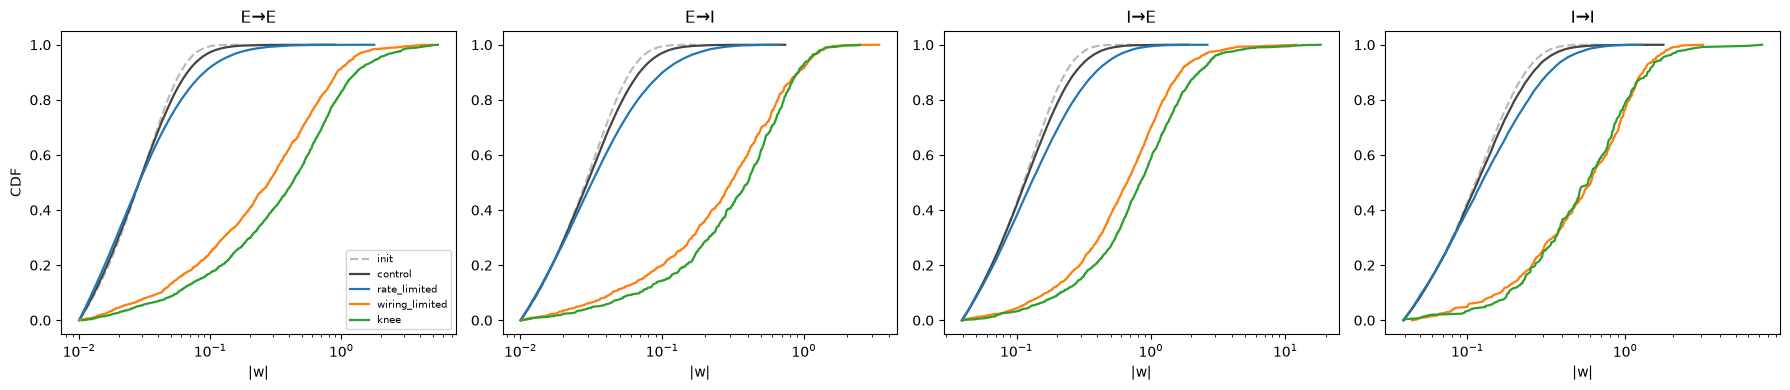

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, b in zip(axes, BLOCKS):
    for p in ORDER:
        v = np.sort(VALS[(p, b)])
        if len(v):
            ax.plot(v, np.linspace(0, 1, len(v)), color=COL[p], lw=1.6, ls="--" if p == "init" else "-", label=p)
    ax.set_xscale("log"); ax.set_title(b); ax.set_xlabel("|w|")
axes[0].set_ylabel("CDF"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 2.3 Per-block summary across seeds
Density, median strength, total weight and shape (std of log|w|; top-10% share = how heavy-tailed).

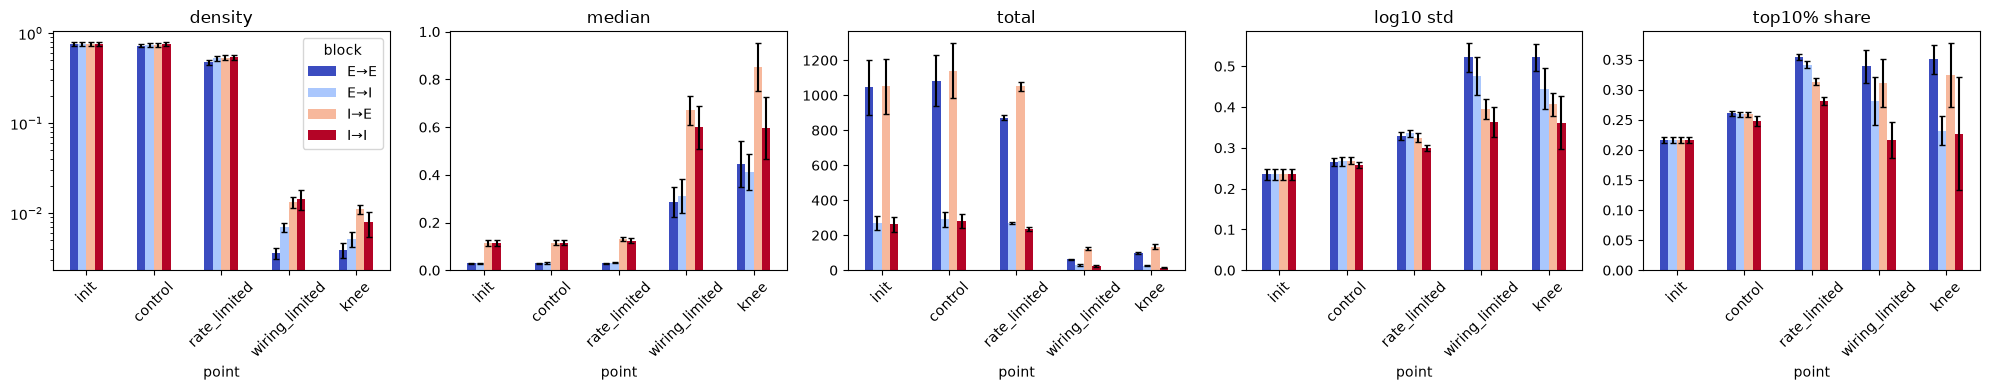

In [21]:
metrics = ["density", "median", "total", "log10 std", "top10% share"]
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
for ax, m in zip(axes, metrics):
    piv = wstats.groupby(["point", "block"])[m].agg(["mean", "std"]).unstack("block").reindex(ORDER)
    piv["mean"].plot.bar(yerr=piv["std"], ax=ax, capsize=2, colormap="coolwarm", rot=45, legend=(m == metrics[0]))
    ax.set_title(m)
axes[0].set_yscale("log")
plt.tight_layout(); plt.show()

## 2.4 E/I balance per neuron

Total recurrent excitatory vs inhibitory input to each neuron (column sums of W's positive and negative
parts). On core5 this was the clearest effect: constrained networks became inhibition-dominated.

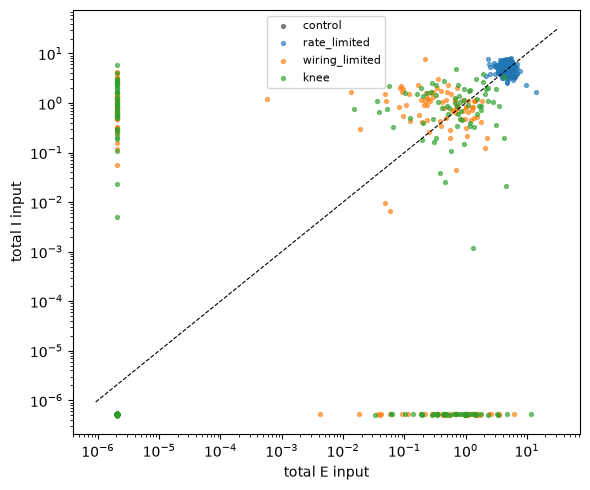

I/E (median)        corr(E in, I in)       
                       mean    std             mean    std
point                                                     
control               1.033  0.017           -0.310  0.071
rate_limited          1.152  0.028           -0.250  0.071
wiring_limited        0.474  0.322           -0.000  0.045
knee                  0.256  0.000            0.107  0.061

In [22]:
rows = []
fig, ax = plt.subplots(figsize=(6, 5))
for p in POINTS:
    for s in seeds(p):
        _, ck, W = load(p, s)
        e, i = np.clip(W, 0, None).sum(axis=0), -np.clip(W, None, 0).sum(axis=0)
        if s == REP[p]:
            ax.scatter(e, i, s=8, color=COLORS[p], alpha=0.6, label=p)
        rows.append({"point": p, "seed": s, "I/E (median)": np.median(i / np.maximum(e, 1e-12)),
                     "corr(E in, I in)": np.corrcoef(e, i)[0, 1]})
ax.set_xscale("log"); ax.set_yscale("log")
lims = ax.get_xlim(); ax.plot(lims, lims, "k--", lw=0.8)
ax.set_xlabel("total E input"); ax.set_ylabel("total I input"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).groupby("point")[["I/E (median)", "corr(E in, I in)"]].agg(["mean", "std"]).reindex(POINTS).round(3))

# Readout

*(Fill in after running on the real zoom run.)*

1. **Clusters:** silhouette excess over the shuffled null, k and tasks-per-neuron, control vs constrained,
   and whether it survives 1.4.
2. **Weights:** which blocks the wiring budget prunes, whether the surviving weights get stronger / heavier
   tailed, and what the rate budget does to them.